# Homework 1 



**Instructions:** Download this jupyer notebook (button at the top of the page) and complete the code where needed. Once you have completed the code, run the entire notebook, save a PDF and submit it on Canvas.

In [142]:
import abc
from typing import Callable
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import functools

## Problem 1
In this problem, you will familiarize yourself with the basic operations with dynamics systems and useful JAX operations.

Given the following dynamics class below.

In [143]:
class Dynamics(metaclass=abc.ABCMeta):
    dynamics_func: Callable
    state_dim: int
    control_dim: int

    def __init__(self, dynamics_func, state_dim, control_dim):
        self.dynamics_func = dynamics_func
        self.state_dim = state_dim
        self.control_dim = control_dim

    def __call__(self, state, control, time=0):
        return self.dynamics_func(state, control, time)

### (a) Setting up dynamics
Using the `Dynamics` class, construct the continuous time dynamics for the dynamically extended unicycle model.

$$
    \dot{\mathbf{x}} = \begin{bmatrix}
        \dot{x} \\ \dot{y} \\ \dot{\theta} \\ \dot{v}
    \end{bmatrix} = \begin{bmatrix}
        v\cos\theta \\ v\sin\theta \\ \omega \\ a
    \end{bmatrix}, \qquad u=(\omega, a)
$$

In [144]:
def dynamic_unicycle_ode(state, control, time):
    x, y, theta, v = state
    omega, a = control
    x_dot = v * jnp.cos(theta)
    y_dot = v * jnp.sin(theta)
    theta_dot = omega
    v_dot = a
    return jnp.array([x_dot, y_dot, theta_dot, v_dot])
    # '''
    # fill code here
    # '''
    # raise NotImplementedError # remove this


state_dim = 4
control_dim = 2
continuous_dynamics = Dynamics(dynamic_unicycle_ode, state_dim, control_dim)

### (b) Obtaining discrete-time dynamics

With the continuous time dynamics, we can obtain the discrete time dynamics by integrating over a time step $\Delta t$.

Implement both Euler integation and Runge-Kutta integration to obtain the discrete-time dynamics.

In [145]:
def euler_integrate(dynamics, dt):
    # zero-order hold
    def integrator(x, u, t):
        x_next = x + dt * dynamics(x, u, t)
        return x_next

    return integrator
    #     '''
    #     fill code here
    #     '''
    #     raise NotImplementedError # remove this
    # return integrator


def runge_kutta_integrator(dynamics, dt=0.1):
    # zero-order hold
    def integrator(x, u, t):
        dt2 = dt / 2.0
        k1 = dynamics(x, u, t)
        k2 = dynamics(x + dt2 * k1, u, t + dt2)
        k3 = dynamics(x + dt2 * k2, u, t + dt2)
        k4 = dynamics(x + dt * k3, u, t + dt)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return integrator
    #     '''
    #     fill code here
    #     '''
    #     raise NotImplementedError # remove this
    # return integrator

In [146]:
dt = 0.1
discrete_dynamics_euler = Dynamics(
    euler_integrate(continuous_dynamics, dt), state_dim, control_dim
)
discrete_dynamics_rk = Dynamics(
    runge_kutta_integrator(continuous_dynamics, dt), state_dim, control_dim
)

### (c) Simulating dynamics

Simulate your dynamics over 5 seconds for different values of $\Delta t$ and compare the trajectories. 

Show on the same plot, the simulated trajectories for the following cases:
- Discrete-time dynamics with Euler integration, $\Delta t = 0.01$
- Discrete-time dynamics with Euler integration, $\Delta t = 0.5$
- Discrete-time dynamics with RK integration, $\Delta t = 0.01$
- Discrete-time dynamics with RK integration, $\Delta t = 0.5$

How does the choice of integration scheme and time step size influence the resulting trajectories? Feel free to try different time step values, but you don't need to submit plots of them.

(np.float64(-1.9964864790439605),
 np.float64(1.890172415971756),
 np.float64(-1.8065099596977234),
 np.float64(2.6547706007957457))

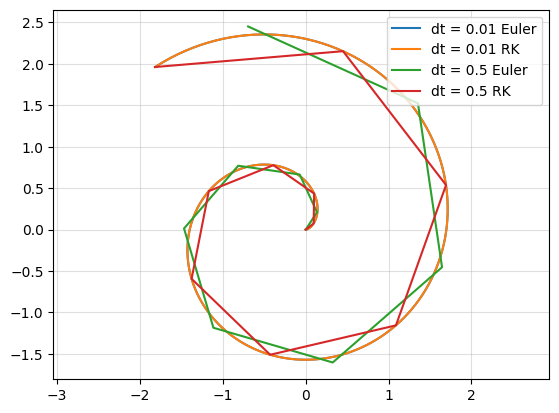

In [147]:
def simulate(dynamics, initial_state, controls, dt):
    xs = [initial_state]
    time = 0
    for u in controls:
        xs.append(dynamics(xs[-1], u, time))
        time += dt
    return jnp.stack(xs)
    # '''
    # fill code here
    # '''
    # raise NotImplementedError # remove this


initial_state = jnp.array([0.0, 0.0, 0.0, 0.0])
control = jnp.array([2.0, 1.0])  # constant control over the 5 second duration.
duration = 5.0
dts = [0.01, 0.5]
for dt in dts:

    num_steps = int(duration / dt)
    controls = [control] * num_steps
    discrete_dynamics_euler = Dynamics(
        euler_integrate(continuous_dynamics, dt), state_dim, control_dim
    )
    discrete_dynamics_rk = Dynamics(
        runge_kutta_integrator(continuous_dynamics, dt), state_dim, control_dim
    )
    xs_euler = simulate(discrete_dynamics_euler, initial_state, controls, dt)
    xs_rk = simulate(discrete_dynamics_rk, initial_state, controls, dt)

    plt.plot(xs_euler[:, 0], xs_euler[:, 1], label=f"dt = {dt} Euler")
    plt.plot(xs_rk[:, 0], xs_rk[:, 1], label=f"dt = {dt} RK")
    plt.legend()
plt.grid(alpha=0.4)
plt.axis("equal")
# add your code here to simulate the system using the euler integrator
# and the runge-kutta integrator for the three different time steps.
# compare the results and plot the trajectories.
# please clearly label the plots and the results.

### (d) `jax.vmap` 
Suppose now that you want to simulate *many* trajectories. Rather than wrapping the `simulate` function in a for loop, we can use `jax.vmap` which is a *vectorize map* function, allowing us to apply a function, in this case `simulate` over multiple inputs.

An example usage of how to use the `jax.vmap` is shown below. Notice that we can specify which argument should be vectorized and along which dimension.

In [148]:
def foo(x, y, z):
    return x + y + z

N = 1000
x = jnp.array(np.random.randn(N))
y = jnp.array(np.random.randn(N))
z = jnp.array(np.random.randn(N))

xs = jnp.array(np.random.randn(N, N))
ys = jnp.array(np.random.randn(N, N))
zs = jnp.array(np.random.randn(N, N))

foo(x, y, z)  # non-vectorized version
# vectorized version for all inputs, 0 is the batch dimension for all inputs
jax.vmap(foo, in_axes=[0, 0, 0])(xs, ys, zs)  

# x not batched, but ys and zs are with 0 as the batch dimension
jax.vmap(foo, in_axes=[None, 0, 0])(x, ys, zs)  

# y not batched, but xs and zs are with 0 as the batch dimension
jax.vmap(foo, in_axes=[0, None, 0])(xs, y, zs)  

# z not batched, but xs and ys are with 0 as the batch dimension
jax.vmap(foo, in_axes=[0, 0, None])(xs, ys, z)  

# x and y not batched, but zs is with 0 as the batch dimension
jax.vmap(foo, in_axes=[None, None, 0])(x, y, zs)  

# vectorized version for all inputs, batch dimension for xs is 1, 
# while 0 is the batch dimension for yx and zs
jax.vmap(foo, in_axes=[1, 0, 0])(xs, ys, zs)  



Array([[ 0.7579985 ,  0.9906481 ,  1.1276435 , ...,  0.27422982,
         1.4859759 , -0.33873278],
       [ 2.2556543 , -1.6937579 , -0.9499146 , ..., -2.085377  ,
         0.06636083,  2.4684503 ],
       [-1.914241  , -0.57093596, -1.9773624 , ...,  0.18281737,
        -2.9603345 , -0.7212801 ],
       ...,
       [-1.5134501 , -0.09827197,  2.314692  , ...,  3.6517184 ,
         4.622944  ,  0.6513872 ],
       [-3.0154018 ,  1.807373  , -0.53529286, ..., -4.336832  ,
         2.5789282 ,  0.7902732 ],
       [ 0.70994556, -1.7703193 , -1.3990922 , ..., -0.62029237,
         3.25417   , -0.49372488]], dtype=float32)

Apply `jax.vmap` for the simulate function for the following batch of initial states and control inputs
Choose $\Delta t = 0.1$.
Use the following values and simulate multiple trajectories using the `jax.vmap` function.


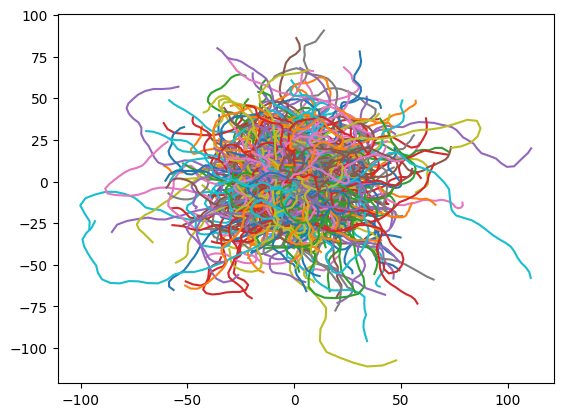

In [149]:
state_dim = continuous_dynamics.state_dim
control_dim = continuous_dynamics.control_dim
N = 1000
n_time_steps = 50
initial_states = jnp.array(np.random.randn(N, state_dim))
controls = jnp.array(np.random.randn(N, n_time_steps, control_dim))

trajs = jax.vmap(simulate, in_axes=[None, 0, 0, None])(
    discrete_dynamics_rk, initial_states, controls, jnp.array(dt)
)

[plt.plot(tj[:, 0], tj[:, 1]) for tj in trajs];

### (e) `jax.jit` (optional reading)

Bleh! You notice that it takes some time to run it. And if you increased the duration or number of trajectories to simulate, the computation would increase.
If only we could compile the code to help reduce computation time. With JAX, you can! We can use the `jax.jit` function that performs just-in-time compilation. JAX will figure out the expected sizes of the input arrays and allocate memory based on that.

There are number of ways to just `jax.jit`, and it can get a bit tricky as your code becomes more complex. Best to read up the JAX documentation for more information.
But for relatively simple functions, you can usually just apply `jax.jit` without any fuss, and get significant speedup in your code.

In [150]:
# without jitting
%timeit jax.vmap(simulate, in_axes=[None, 0, 0, None])(discrete_dynamics_rk, initial_states, controls, jnp.array(dt))

457 ms ± 12.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [151]:
# method 1: directly apply jax.jit over the jax.vmap function
# need to provide the static_argnums argument to the first argument since that is a function input and not an array input
sim_jit = jax.jit(jax.vmap(simulate, in_axes=[None, 0, 0, None]), static_argnums=0)
        
# time the run
%timeit sim_jit(discrete_dynamics_rk, initial_states, controls, jnp.array(dt)).block_until_ready()

13.7 ms ± 344 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [152]:
# method 2: apply jax.jit over the simulate function and then apply jax.vmap
sim_jit = jax.jit(simulate, static_argnums=0)
sim_jit_vmap = jax.vmap(sim_jit, in_axes=[None, 0, 0, None])
%timeit sim_jit_vmap(discrete_dynamics_rk, initial_states, controls, jnp.array(dt)).block_until_ready()

13.9 ms ± 339 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [153]:
# Method 3: apply jax.jit over the simulate function during function construction and then apply jax.vmap
@functools.partial(jax.jit, static_argnames=("dynamics"))
def simulate(dynamics, initial_state, controls, dt):
    xs = [initial_state]
    time = 0
    for u in controls:
        xs.append(dynamics(xs[-1], u, time))
        time += dt
    return jnp.stack(xs)

sim_jit_vmap = jax.vmap(simulate, in_axes=[None, 0, 0, None])
%timeit sim_jit_vmap(discrete_dynamics_rk, initial_states, controls, jnp.array(dt)).block_until_ready()

14.1 ms ± 297 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Problem 2

We continue to consider the dynamically-extended unicycle model and investigate a way to linearize the dynamics around any state. 
First, we will perform the linearization analytically, and then leverage modern computation tools which will be incredibly helpful especially if the dynamics are complicated!
We can efficiently compute gradients via automatic differentiation.
JAX is an automatic differentiation library. 

### (a) 

In [ ]:
For the 